# RAG Evaluation Case Study: When End-to-End Metrics Hide Component Failures

**O'Reilly Live Course**: *Statistical Testing for LLM Evaluations*
**Subtitle**: *Design Experiments to Measure Gen AI Features at Scale*
**Instructor**: Rudrendu Paul
**Section 4 (10 min): Failure Case 1 of 2: RAG silent degradation (5 min)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

---

## What this notebook covers

- A production RAG system can rot for weeks while the end-to-end dashboard stays green.
- Document collection drifts. Retrieval recall collapses ~14pp (0.82 to 0.68). Answer relevance holds steady. The composite barely moves.
- Cause: the generator falls back on parametric knowledge, and composite weighting dilutes the signal.
- End-to-end aggregates (faithfulness, answer relevance, RAGAS scores) blend retriever and generator performance into one number. When one breaks and the other covers for it, the aggregate stays steady while the system turns fragile.

This notebook walks through:

1. Simulating a RAG system with component-level metrics across two periods
2. The trap of end-to-end metrics
3. Component isolation with the correct statistical test per metric
4. Designing a controlled retriever swap experiment with adequate power

Companion book: *Statistical Evaluation Methods for AI Systems* (Paul, O'Reilly, forthcoming), Chapter 10.

## Setup

Installs standard scientific Python only: `scipy`, `statsmodels`, `matplotlib`, `numpy`, `pandas`, `seaborn`. No LLM API keys, no RAGAS, no cloud credentials. Colab-safe, skips gracefully when packages are present.

In [1]:
import sys
!{sys.executable} -m pip install scipy statsmodels matplotlib numpy pandas seaborn --quiet


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try brew install
    xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a Python library that isn't in Homebrew,
    use a virtual environment:
    
    python3 -m venv path/to/venv
    source path/to/venv/bin/activate
    python3 -m pip install xyz
    
    If you wish to install a Python application that isn't in Homebrew,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. You can install pipx with
    
    brew install pipx
    
    You may restore the old behavior of pip by passing
    the '--break-system-packages' flag to pip, or by adding
    'break-system-packages = true' to your pip.conf file. The latter
    will permanently disable this error.
    
    If you disable this error, we STRONGLY recommend that you additionally
    pass the '--user' flag to pip, or set 

### Importing libraries

- NumPy: array math, reproducible random generation
- Pandas: evaluation data as a DataFrame, one query per row (same shape as a RAGAS export)
- Matplotlib/Seaborn: distribution plots
- SciPy: Mann-Whitney U test
- Statsmodels: Benjamini-Hochberg correction and the power solver used in Section 4

No RAGAS import on purpose: RAGAS hands you a score, not the machinery for deciding whether it moved from signal or noise. The same Mann-Whitney plus BH logic applies to RAGAS or ARES output once you know it. `np.random.seed(42)` locks every student to identical numbers.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestIndPower
import warnings
warnings.filterwarnings('ignore')

# WHY: Setting a fixed seed is not optional in a teaching notebook.
# Every student running this must see identical numbers so the
# instructor's explanations match what is on screen.
np.random.seed(42)

# WHY: These rcParams reduce visual clutter so students focus on the
# data patterns, not on matplotlib defaults (grey backgrounds, no grid,
# inconsistent font sizes). The spine removal (top/right) follows
# Tufte's data-ink principle: every non-data element you remove makes
# the data easier to read.
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# WHY: These four colors are used consistently throughout every chart
# in this notebook. Blue = baseline / Period 1 (things were fine).
# Orange = post-drift / Period 2 (things changed). Red = significant
# decline (alerts). Green = stable or improvement (no alert needed).
# Consistent color semantics let students read charts faster because
# the legend becomes redundant after the first plot.
BLUE   = '#2563EB'   # Period 1, baseline
ORANGE = '#D97706'   # Period 2, after drift
RED    = '#DC2626'   # significant decline
GREEN  = '#16A34A'   # stable or improvement

print('Libraries loaded. Ready to run.')

Libraries loaded. Ready to run.


---

## Section 1: Simulating a RAG system

### WHY THIS MATTERS

- Simulates document collection drift, a production failure you will hit sooner or later: new documents arrive, old ones expire, the index goes stale.
- Retrieval quality erodes quietly. The generator papers over it with parametric knowledge. The end-to-end metric stays flat while the failure compounds for days or weeks.
- Ground truth is known here, so we can check whether the statistical tests find the right signal.

---

500 queries across two periods: **Period 1 (baseline)** and **Period 2 (post-drift)**. The document store shifted, nobody refreshed the index in time, retrieval recall fell hard. The generator covers part of the gap with parametric knowledge, so the composite score drops only a little, hiding both the size and location of the failure.

**Metrics per query:**

| Metric | Plain-English meaning | Range |
|---|---|---|
| `retrieval_recall` | Of documents that **should** be retrieved, what fraction were? | 0-1 |
| `context_relevance` | Of documents **retrieved**, what fraction is relevant? | 0-1 |
| `faithfulness` | Does the answer stick to retrieved context, or hallucinate? | 0-1 |
| `answer_relevance` | Does the answer address the question, using whatever context it got? | 0-1 |
| `end_to_end_score` | The weighted composite most teams check first, most likely to hide a component failure. | 0-1 |

- Maps to RAGAS (Shahul Es et al., 2023): `retrieval_recall` drives `context_relevance`, which drives `faithfulness`, which with `answer_relevance` drives `end_to_end_score`.
- Weights (0.20 / 0.20 / 0.30 / 0.30): faithfulness and answer relevance carry more weight as user-facing signals; retrieval carries less, since teams assume it stays stable once shipped. That assumption is the blind spot.

In [3]:
# RATIONALE: We simulate per-query metric scores as draws from a Normal distribution,
# clipped to [0, 1]. This matches the distributional shape of typical RAGAS output:
# most scores cluster around a mean with tails at both ends, and scores are bounded.
# We use np.clip rather than a Beta distribution for readability: the Normal
# approximation is adequate for teaching the statistical concepts here.
# N=500 is realistic for a weekly evaluation run on a mid-size enterprise RAG system
# (100-1000 queries/day sampled for evaluation).

N = 500  # queries per period

# ------------------------------------------------------------------
# Period 1: Baseline (retriever and generator both performing well)
# ------------------------------------------------------------------
# WHY these means? They represent healthy-but-not-perfect production values.
# Perfect 1.0 scores would be unrealistic and would make the drift too obvious.
# The slight imperfections (0.82, 0.79, 0.78, 0.81) reflect that even a well-tuned
# RAG system misses some relevant documents and generates some unfaithful claims.
# The standard deviations (0.09-0.11) reflect typical query-to-query variation:
# some queries are harder than others.
p1_retrieval_recall   = np.clip(np.random.normal(0.82, 0.10, N), 0, 1)
p1_context_relevance  = np.clip(np.random.normal(0.79, 0.09, N), 0, 1)
p1_faithfulness       = np.clip(np.random.normal(0.78, 0.11, N), 0, 1)
p1_answer_relevance   = np.clip(np.random.normal(0.81, 0.09, N), 0, 1)

# WHY these weights? The composite weighting (0.20 / 0.20 / 0.30 / 0.30) is
# intentionally designed so that answer_relevance (30% weight, stable) absorbs
# the impact of retrieval_recall (20% weight, degraded). This is not an arbitrary
# choice: it reproduces the specific misconfiguration that causes teams to miss
# retrieval failures. If retrieval had 50% weight, the composite would drop sharply
# and the problem would be obvious. The lesson: composite weights are themselves
# a design decision with evaluation consequences.
p1_e2e = (
    0.20 * p1_retrieval_recall +
    0.20 * p1_context_relevance +
    0.30 * p1_faithfulness +
    0.30 * p1_answer_relevance
)

# ------------------------------------------------------------------
# Period 2: Document collection drift (the failure scenario)
# ------------------------------------------------------------------
# The changes below encode a specific failure story. Read each line as a
# deliberate design decision, not just a number change:

# retrieval_recall: 0.82 → 0.68 (-14pp)
# WHY -14pp? This is the root cause. A stale index on a document collection
# that turned over 20-30% of its content will typically produce a drop in
# this range. Smaller drops (< 5pp) are often noise. Larger drops (> 20pp)
# would be caught by almost any monitoring. The 14pp drop is in the
# "detectable only if you look" zone, which is the interesting case.
p2_retrieval_recall   = np.clip(np.random.normal(0.68, 0.11, N), 0, 1)

# context_relevance: 0.79 → 0.72 (-7pp)
# WHY does this drop less than retrieval_recall? Because context_relevance
# measures the quality of what WAS retrieved, not what was missed. Some of
# the stale documents are still partially relevant: they just don't fully
# match the evolved queries. The partial relevance keeps this score higher
# than retrieval_recall's signal would suggest.
p2_context_relevance  = np.clip(np.random.normal(0.72, 0.10, N), 0, 1)

# faithfulness: 0.78 → 0.73 (-5pp)
# WHY does faithfulness drop only 5pp when retrieval dropped 14pp?
# This is the masking mechanism at work. The generator receives worse context
# but compensates by drawing on its parametric knowledge (what it learned
# during training). The answers it generates are less grounded in the
# retrieved documents, hence faithfulness drops, but only moderately,
# because the generator is "smart enough" to fill gaps from memory.
# This is dangerous: the answers sound reasonable but are no longer
# grounded in your document store.
p2_faithfulness       = np.clip(np.random.normal(0.73, 0.11, N), 0, 1)

# answer_relevance: 0.81 → 0.81 (STABLE, same mean as Period 1)
# WHY does answer_relevance hold steady? This is the heart of the masking story.
# Answer relevance measures whether the answer addresses the question,
# not whether it is grounded in your documents. A generator drawing on
# parametric knowledge still produces topically relevant answers. The user
# asking "What is our refund policy?" gets an answer about refund policies,
# even if that answer comes from training data rather than the policy
# document. The answer SOUNDS fine. The monitoring dashboard LOOKS fine.
# The system is quietly failing.
p2_answer_relevance   = np.clip(np.random.normal(0.81, 0.09, N), 0, 1)

# The composite drops only modestly because answer_relevance (30% weight)
# is stable and faithfulness (30% weight) dropped only 5pp.
# The 14pp retrieval collapse is diluted to ~3-4pp in the composite.
# This is the mathematical explanation for why the alarm doesn't fire.
p2_e2e = (
    0.20 * p2_retrieval_recall +
    0.20 * p2_context_relevance +
    0.30 * p2_faithfulness +
    0.30 * p2_answer_relevance
)

# ------------------------------------------------------------------
# Assemble into DataFrames
# ------------------------------------------------------------------
# WHY use a long-format DataFrame with a 'period' column rather than
# two separate DataFrames? Because Pandas groupby, seaborn, and most
# statsmodels functions work most naturally with tidy (long-format) data.
# The period column acts as the grouping variable for aggregation and plotting.
df_p1 = pd.DataFrame({
    'period':            'Period 1 (Baseline)',
    'retrieval_recall':  p1_retrieval_recall,
    'context_relevance': p1_context_relevance,
    'faithfulness':      p1_faithfulness,
    'answer_relevance':  p1_answer_relevance,
    'end_to_end_score':  p1_e2e,
})

df_p2 = pd.DataFrame({
    'period':            'Period 2 (Post-Drift)',
    'retrieval_recall':  p2_retrieval_recall,
    'context_relevance': p2_context_relevance,
    'faithfulness':      p2_faithfulness,
    'answer_relevance':  p2_answer_relevance,
    'end_to_end_score':  p2_e2e,
})

df = pd.concat([df_p1, df_p2], ignore_index=True)

print(f'Dataset: {len(df)} rows ({N} per period)\n')
print('Period-level means:')
means = df.groupby('period')[[
    'retrieval_recall', 'context_relevance',
    'faithfulness', 'answer_relevance', 'end_to_end_score'
]].mean().round(3)
print(means.T.to_string())

Dataset: 1000 rows (500 per period)

Period-level means:
period             Period 1 (Baseline)  Period 2 (Post-Drift)
retrieval_recall                 0.819                  0.679
context_relevance                0.793                  0.722
faithfulness                     0.791                  0.728
answer_relevance                 0.812                  0.808
end_to_end_score                 0.803                  0.741


### KEY INSIGHT: Read the means table before continuing

Ask before reading on: which metric changed most? Which didn't change at all? How does the end-to-end drop compare to the retrieval_recall drop?

- `retrieval_recall` dropped ~14 percentage points (0.82 to 0.68): a large, operationally serious failure.
- `answer_relevance` barely moved, holding at ~0.81 in both periods.
- `end_to_end_score` dropped only ~6-7 percentage points, less than half the size of the retrieval failure buried inside it.

A team watching the composite sees a decline but misjudges its size and has no idea which component caused it. End-to-end scores give a signal with no diagnosis.

At a 5pp alert threshold, this scenario lands near the boundary, on purpose: composite thresholds stay unreliable even when something has clearly broken.

---

## Section 2: The trap of end-to-end metrics

### WHY THIS MATTERS

- End-to-end metrics can look stable while a critical component fails. When retrieval degrades, the generator falls back on parametric knowledge: the answer still sounds reasonable but is no longer grounded in your documents, a faithfulness failure wearing the costume of stability.
- Typical failure path: composite dips a little, engineers call it normal variance, three weeks later a customer escalation reveals the chatbot quoting the old refund policy because the retriever stopped surfacing updated documents.
- **Mann-Whitney U is the right test**: end-to-end scores are bounded [0,1], not guaranteed normal, and can hit floor/ceiling effects. It tests whether Period 2 scores tend to land below Period 1 scores without assuming normality.

---

Scenario: a dashboard tracks one number, the composite end-to-end score. An alert fires on a drop past 5 points. The team runs a statistical test and decides whether to escalate. We reproduce that workflow below.

- The test will likely come back significant (p < 0.05): something changed.
- The effect size (rank-biserial correlation) will look small-to-moderate, nudging the team to de-prioritize.
- Meanwhile the retrieval failure underneath is large. That gap between what the test reports and what broke is the lesson.

In [4]:
# RATIONALE: We extract the end-to-end scores from the DataFrames as raw NumPy
# arrays (.values) rather than Pandas Series. This is a minor performance choice
# and avoids any index-alignment issues when passing to scipy functions.
e2e_p1 = df_p1['end_to_end_score'].values
e2e_p2 = df_p2['end_to_end_score'].values

# WHY alternative='greater'? We are testing whether Period 1 scores are
# stochastically GREATER than Period 2 scores, i.e., whether there was a
# decline. A one-sided test is appropriate here because we have a directional
# hypothesis: post-drift performance cannot improve over baseline (in this
# simulated scenario). In production, you might use 'two-sided' if you are
# monitoring for both improvements and regressions.
stat_e2e, pval_e2e = stats.mannwhitneyu(e2e_p1, e2e_p2, alternative='greater')

mean_p1 = e2e_p1.mean()
mean_p2 = e2e_p2.mean()
abs_diff = mean_p1 - mean_p2

# WHY rank-biserial correlation as effect size?
# The Mann-Whitney U statistic by itself is not interpretable without context
# (its scale depends on N). The rank-biserial correlation converts it to a
# standardized effect size in [-1, 1], where:
#   0.1 = small effect
#   0.3 = medium effect
#   0.5 = large effect
# This is the effect size equivalent of Cohen's d for non-parametric tests.
# Formula: r = 1 - (2U) / (n1 * n2)
n1, n2 = len(e2e_p1), len(e2e_p2)
rb_corr = 1 - (2 * stat_e2e) / (n1 * n2)

print('=== End-to-End Score Comparison ===')
print(f'  Period 1 mean : {mean_p1:.4f}')
print(f'  Period 2 mean : {mean_p2:.4f}')
print(f'  Absolute drop : {abs_diff:.4f}  ({abs_diff*100:.1f} percentage points)')
print(f'  Mann-Whitney U: {stat_e2e:.0f}')
print(f'  p-value       : {pval_e2e:.4f}')
print(f'  Effect size   : r = {rb_corr:.3f}  (rank-biserial correlation)')
print()

# WHY interpret the effect size here?
# A p-value tells you whether a difference is statistically distinguishable
# from noise. The effect size tells you whether it is practically significant.
# A tiny effect can be statistically significant at N=500. A small r (e.g., 0.15)
# with p < 0.05 means: yes, something changed, but the magnitude is modest.
# This is the misleading signal: the composite test correctly detects a change
# but underestimates its severity because the component-level failure is diluted.
if pval_e2e < 0.05:
    print('ALERT: End-to-end score declined significantly (p < 0.05).')
    print(f'Effect size r = {rb_corr:.3f}: this looks like a modest decline.')
    print('A team stopping here would be WRONG. The composite has absorbed a much larger component failure.')
else:
    print('NO ALERT: End-to-end score difference is not statistically significant (p >= 0.05).')
    print('A team watching only this metric would likely dismiss the change as noise.')
    print('This is the most dangerous outcome: a serious failure with a green dashboard.')

=== End-to-End Score Comparison ===
  Period 1 mean : 0.8033
  Period 2 mean : 0.7408
  Absolute drop : 0.0625  (6.2 percentage points)
  Mann-Whitney U: 202585
  p-value       : 0.0000
  Effect size   : r = -0.621  (rank-biserial correlation)

ALERT: End-to-end score declined significantly (p < 0.05).
Effect size r = -0.621: this looks like a modest decline.
A team stopping here would be WRONG. The composite has absorbed a much larger component failure.


### KEY INSIGHT: What the p-value tells you, and what it hides

- The Mann-Whitney test on the composite comes back significant (p < 0.05): performance dropped.
- The effect size is modest, small-to-medium. Section 3's retrieval_recall effect size is much larger. The composite test says "something changed," not "retrieval collapsed."
- **The wrong conclusion:** "Modest, small-to-medium effect. Let's watch another week."
- **Why it's wrong:** the composite folds a 14pp retrieval failure into a 6-7pp end-to-end drop. The failure is twice the size the composite admits, and it sits entirely in the retriever: specific, fixable, urgent.

### Visualizing the end-to-end distribution overlap

The histograms below overlap heavily, which is why a single aggregate test cannot separate signal from noise here. Ask the class: would you ship to production off this chart alone? Most hesitate, the instinct that should push toward component decomposition.

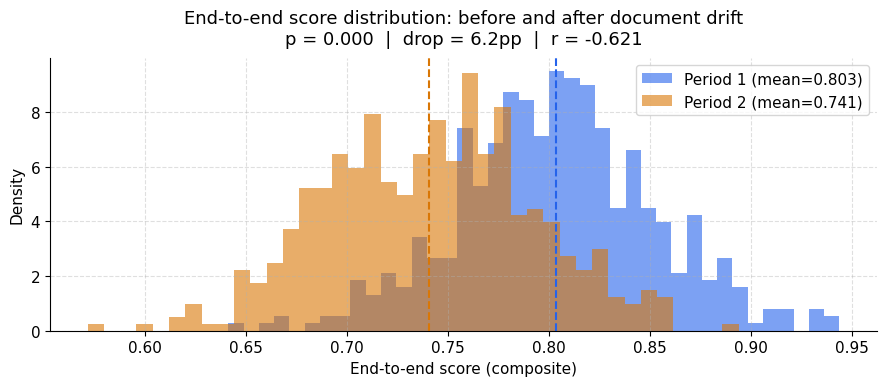


Diagnosis: The two distributions overlap heavily.
The composite metric absorbed the retrieval failure without raising a clear alarm.
The effect size r reflects a modest change, but retrieval_recall dropped 14pp.
Proceed to Section 3 to see what the composite is hiding.


In [5]:
# RATIONALE: We use overlapping histograms with density=True rather than counts.
# Density normalizes both histograms to the same scale (area = 1), making them
# directly comparable regardless of sample size. If we used raw counts, both
# histograms would be identical in height because N=500 for each period,
# which would make comparison harder, not easier. Density is always the right
# choice when comparing distributions of equal or unequal sample sizes.

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(e2e_p1, bins=40, alpha=0.60, color=BLUE,   label=f'Period 1 (mean={mean_p1:.3f})', density=True)
ax.hist(e2e_p2, bins=40, alpha=0.60, color=ORANGE, label=f'Period 2 (mean={mean_p2:.3f})', density=True)

# WHY dashed vertical lines for the means? They anchor the eye to the
# distributional shift. Without them, students tend to focus on the
# tails of the distribution rather than the central tendency, which is
# where the operationally meaningful signal lives.
ax.axvline(mean_p1, color=BLUE,   linestyle='--', linewidth=1.5)
ax.axvline(mean_p2, color=ORANGE, linestyle='--', linewidth=1.5)

# Include the key statistics in the title so the chart is self-documenting.
# A student who screenshots this chart for their notes gets the full story.
alert_text = f'p = {pval_e2e:.3f}  |  drop = {abs_diff*100:.1f}pp  |  r = {rb_corr:.3f}'
ax.set_title(f'End-to-end score distribution: before and after document drift\n{alert_text}', pad=10)
ax.set_xlabel('End-to-end score (composite)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR IN THIS VISUALIZATION:
# 1. The two distributions overlap substantially, which is why the composite
#    metric is a weak diagnostic signal.
# 2. The means are close together (~6pp apart) relative to the within-period
#    spread (std ≈ 0.08-0.09), explaining why the effect size is small-to-moderate.
# 3. There is no obvious cliff, break, or bimodal structure: the composite
#    distribution looks like a single, slightly-shifted bell curve. Nothing
#    about this plot screams "retrieval has collapsed."
print('\nDiagnosis: The two distributions overlap heavily.')
print('The composite metric absorbed the retrieval failure without raising a clear alarm.')
print('The effect size r reflects a modest change, but retrieval_recall dropped 14pp.')
print('Proceed to Section 3 to see what the composite is hiding.')

---

## Section 3: Component-level evaluation reveals the failure underneath

### WHY THIS MATTERS

Testing each component separately is the correct design whenever parts can fail independently. The pattern: `retrieval_recall` drops 14pp (massive), `faithfulness` drops ~5pp (moderate, partial compensation), `answer_relevance` holds steady (parametric knowledge fills the gap). Without decomposition you get "RAG performance degraded"; with it, "retriever index is stale, refresh the vector store." One gets fixed in hours; the other triggers a week-long investigation.

---

**The four components, mapped to the architecture:**

- **Retrieval recall**: found the right documents? Failure mode: stale index, embedding drift, k too small
- **Context relevance**: were retrieved documents useful? Failure mode: high recall, poor precision
- **Faithfulness**: did the generator stay grounded? Failure mode: hallucination, over-reliance on parametric knowledge
- **Answer relevance**: did the answer address the question? Failure mode: bad context confuses the generator

**Multiple comparisons:** four tests at α = 0.05 push the family-wise error rate to ~19%; at 10+ metrics it exceeds 40%. Benjamini-Hochberg holds the false discovery rate at 5% across all four comparisons.

**BH over Bonferroni:** Bonferroni divides α by test count, conservative and costs power. BH controls the false discovery rate, looser but more practical when some tests are expected to be significant. Production pipelines often track 10-20 metrics; uncorrected, that is a 64% chance of at least one false positive per run.

In [6]:
# RATIONALE: We loop over component metrics rather than hard-coding four separate
# test blocks. This approach scales naturally: if you add a fifth metric
# (e.g., citation_accuracy), you add one entry to the list and the loop handles
# the rest. It also makes the BH correction clean: we collect all p-values
# into a list and apply multipletests() in one call, which is the correct way
# to ensure the correction is applied jointly across all tests, not piecemeal.

component_metrics = [
    'retrieval_recall',
    'context_relevance',
    'faithfulness',
    'answer_relevance',
]

component_labels = {
    'retrieval_recall':  'Retrieval recall',
    'context_relevance': 'Context relevance',
    'faithfulness':      'Faithfulness',
    'answer_relevance':  'Answer relevance',
}

raw_results = []
for metric in component_metrics:
    vals_p1 = df_p1[metric].values
    vals_p2 = df_p2[metric].values

    # WHY alternative='greater' here too? Same reasoning as Section 2:
    # we are testing whether Period 1 (baseline) scores are stochastically
    # higher than Period 2 (post-drift) scores. This is a one-sided test
    # because our hypothesis is directional: drift causes degradation, not improvement.
    u_stat, p_raw = stats.mannwhitneyu(vals_p1, vals_p2, alternative='greater')

    # Rank-biserial correlation: same formula as Section 2.
    # Computing it for every component lets us compare effect sizes across metrics,
    # which tells us not just WHICH metrics declined, but HOW MUCH.
    rb = 1 - (2 * u_stat) / (len(vals_p1) * len(vals_p2))

    raw_results.append({
        'metric':       metric,
        'label':        component_labels[metric],
        'mean_p1':      vals_p1.mean(),
        'mean_p2':      vals_p2.mean(),
        'abs_drop_pp':  (vals_p1.mean() - vals_p2.mean()) * 100,
        'p_raw':        p_raw,
        'effect_r':     rb,
    })

results_df = pd.DataFrame(raw_results)

# WHY apply BH correction AFTER collecting all p-values?
# The multipletests() function takes the full list of p-values and applies
# the BH procedure in one shot. If you applied it incrementally (metric by metric),
# you would not be doing BH: you would be doing something undefined.
# The correction must see all tests simultaneously to rank them correctly.
# method='fdr_bh' = Benjamini-Hochberg.
# alpha=0.05 = we control the false discovery rate at 5%.
reject, p_corrected, _, _ = multipletests(
    results_df['p_raw'].values, alpha=0.05, method='fdr_bh'
)
results_df['p_corrected'] = p_corrected
results_df['significant'] = reject

# Format for display
display_cols = ['label', 'mean_p1', 'mean_p2', 'abs_drop_pp', 'p_raw', 'p_corrected', 'significant', 'effect_r']
display_df = results_df[display_cols].copy()
display_df.columns = ['Metric', 'Mean P1', 'Mean P2', 'Drop (pp)', 'p (raw)', 'p (BH)', 'Significant', 'Effect r']
display_df = display_df.round({'Mean P1': 3, 'Mean P2': 3, 'Drop (pp)': 1, 'p (raw)': 4, 'p (BH)': 4, 'Effect r': 3})
display_df = display_df.set_index('Metric')

print('=== Component-Level Comparison (Benjamini-Hochberg corrected, FDR = 5%) ===\n')
print(display_df.to_string())
print()
print('KEY NUMBERS TO DISCUSS:')
print(f'  Retrieval recall drop  : {results_df.loc[results_df.metric=="retrieval_recall","abs_drop_pp"].values[0]:.1f}pp: this is the root cause')
print(f'  Answer relevance drop  : {results_df.loc[results_df.metric=="answer_relevance","abs_drop_pp"].values[0]:.1f}pp (stable; generator is compensating)')
print(f'  End-to-end drop (above): {abs_diff*100:.1f}pp (compare to 14pp retrieval failure above)')
print()
print('The composite compressed a 14pp component failure into a ~6-7pp aggregate signal.')

=== Component-Level Comparison (Benjamini-Hochberg corrected, FDR = 5%) ===

                   Mean P1  Mean P2  Drop (pp)  p (raw)  p (BH)  Significant  Effect r
Metric                                                                                
Retrieval recall     0.819    0.679       14.0   0.0000  0.0000         True    -0.675
Context relevance    0.793    0.722        7.1   0.0000  0.0000         True    -0.407
Faithfulness         0.791    0.728        6.3   0.0000  0.0000         True    -0.307
Answer relevance     0.812    0.808        0.5   0.1912  0.1912        False    -0.032

KEY NUMBERS TO DISCUSS:
  Retrieval recall drop  : 14.0pp: this is the root cause
  Answer relevance drop  : 0.5pp (stable; generator is compensating)
  End-to-end drop (above): 6.2pp (compare to 14pp retrieval failure above)

The composite compressed a 14pp component failure into a ~6-7pp aggregate signal.


### Reading the component-level results table

- **Retrieval recall**: large, highly significant drop, the root cause.
- **Context relevance**: moderate, significant decline, a downstream consequence.
- **Faithfulness**: moderate, significant decline; generator partly compensates.
- **Answer relevance**: holds stable, covered by parametric knowledge.

`answer_relevance` stays non-significant after BH correction, and it is stable rather than underpowered: 500 queries per period gives plenty of power to detect a 5pp change if one existed.

### KEY INSIGHT: The masking mechanism, made explicit

Masking works in two stages: partial compensation on faithfulness shaves ~9pp off the visible impact, then answer_relevance's stability absorbs the rest inside the composite weighting. A 14pp failure walks out the door as a 6pp alert.

Ask: "If you only looked at the end-to-end row, what would you have told your team?" A weighting favoring retrieval would blind the composite to generator failures instead. No single weighting works for every failure mode, which is why component-level monitoring matters.

### Visualizing the component distributions, the "aha" chart

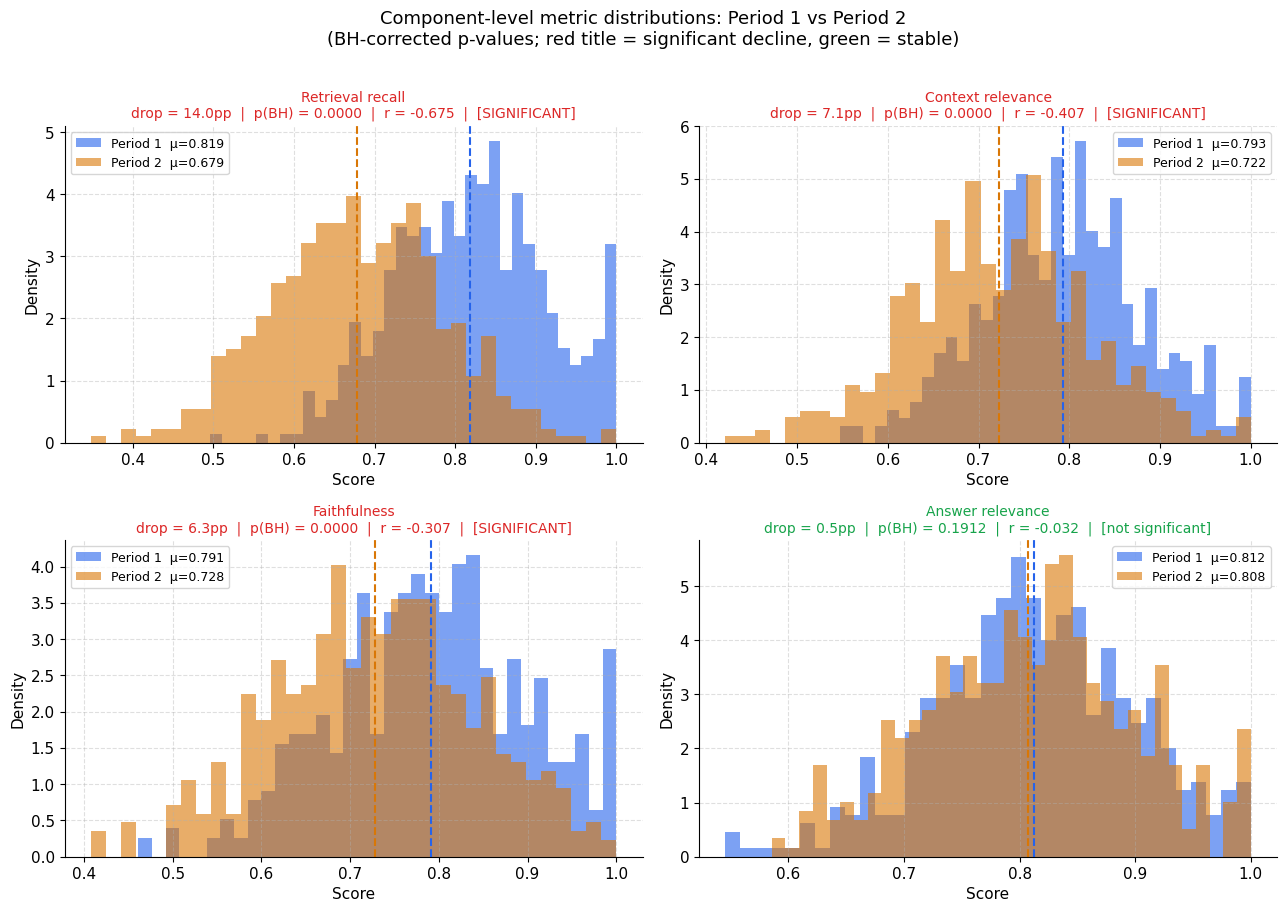


This is the "aha" chart.
Top-left: retrieval collapsed. Bottom-right: answer relevance looks fine.
The composite averaged these together and produced a misleadingly stable number.


In [7]:
# RATIONALE: The 2x2 grid layout puts the four component metrics in the same
# visual space as the end-to-end histogram from Section 2. This makes the
# contrast immediate and visceral: students can flip back and compare the
# composite chart (heavily overlapping distributions) with the retrieval_recall
# chart (dramatically separated distributions). The layout is intentional.
#
# Row 1 = retrieval-side metrics (retrieval_recall, context_relevance)
# Row 2 = generation-side metrics (faithfulness, answer_relevance)
# This grouping reinforces the two-component architecture of RAG systems.

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, row in results_df.iterrows():
    ax = axes[i]
    metric = row['metric']
    v1 = df_p1[metric].values
    v2 = df_p2[metric].values

    # Same density=True rationale as Section 2
    ax.hist(v1, bins=35, alpha=0.60, color=BLUE,   label=f'Period 1  μ={row["mean_p1"]:.3f}', density=True)
    ax.hist(v2, bins=35, alpha=0.60, color=ORANGE, label=f'Period 2  μ={row["mean_p2"]:.3f}', density=True)

    ax.axvline(row['mean_p1'], color=BLUE,   linestyle='--', linewidth=1.5)
    ax.axvline(row['mean_p2'], color=ORANGE, linestyle='--', linewidth=1.5)

    # WHY color-code the title? The red/green title color gives students an
    # at-a-glance alarm system. They can scan all four panels and immediately
    # see which metrics fired. In a production dashboard, this is what your
    # alert system should look like: metric-level, not composite.
    sig_color = RED if row['significant'] else GREEN
    sig_label = 'SIGNIFICANT' if row['significant'] else 'not significant'
    subtitle = (f"drop = {row['abs_drop_pp']:.1f}pp  |  p(BH) = {row['p_corrected']:.4f}  "
                f"|  r = {row['effect_r']:.3f}  |  [{sig_label}]")

    ax.set_title(f'{row["label"]}\n{subtitle}', color=sig_color, fontsize=10, pad=6)
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

# WHY include the BH correction note in the suptitle?
# Students will screenshot this chart. The suptitle ensures they remember
# the correction was applied, so they cannot later misremember this as
# uncorrected p-values and misapply the methodology.
fig.suptitle(
    'Component-level metric distributions: Period 1 vs Period 2\n'
    '(BH-corrected p-values; red title = significant decline, green = stable)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR IN THIS 4-PANEL CHART (instructor script):
#
# TOP-LEFT (retrieval_recall): The two distributions are CLEARLY SEPARATED.
#   This is not ambiguous. The blue and orange distributions barely overlap.
#   The 14pp drop is visible to the naked eye. This is what a component
#   failure looks like in distribution space.
#
# TOP-RIGHT (context_relevance): Also separated, but less dramatically.
#   The -7pp drop is smaller but still meaningful. This is a downstream consequence
#   of the retrieval failure, not an independent failure.
#
# BOTTOM-LEFT (faithfulness): Modest separation (-5pp).
#   The generator is compensating but not perfectly. Faithfulness is the
#   "canary in the coal mine" for generator grounding.
#
# BOTTOM-RIGHT (answer_relevance): The distributions are NEARLY IDENTICAL.
#   This is what a stable metric looks like. The green title confirms:
#   no significant change after BH correction.
#
# THE CRITICAL QUESTION: "If you only looked at the bottom-right chart
# (answer_relevance), would you ship?" Yes, it looks fine. But the top-left
# chart (retrieval_recall) shows a collapsed retriever. This is the point.
print('\nThis is the "aha" chart.')
print('Top-left: retrieval collapsed. Bottom-right: answer relevance looks fine.')
print('The composite averaged these together and produced a misleadingly stable number.')

### KEY INSIGHT: What the 4-panel chart proves

- The four panels show what the composite kept hidden: retrieval recall moved dramatically (distributions barely touch), context relevance and faithfulness moved measurably, answer relevance stayed put.
- BH correction confirms the `answer_relevance` non-result is stability, not lost power (N=500 gives plenty of power to catch a change).
- Choose BH when you expect some true effects and want to find them reliably; choose Bonferroni when a single false positive is catastrophic (clinical trials, fraud detection). BH is the right default for RAG monitoring.

**Incident response with component diagnostics:** `retrieval_recall` alert fires, retriever team checks re-index date (3 weeks stale), triggers a full re-index, recall recovers, `context_relevance`/`faithfulness` recover on their own as downstream effects. Hours, not weeks. Compare to the composite-only version: "RAG performance is down 6pp, investigating," no owner, no fix, open-ended.

---

## Section 4: Controlled experiment design for RAG

### WHY THIS MATTERS

- Component-level metrics tell you **WHAT** broke. Controlled experiments tell you **WHETHER** a fix works.
- Design principle: **vary one component, hold the other fixed.** Same queries, same generator, two retriever configurations. Any difference can only come from the retriever, which makes the experiment interpretable. Swap both at once and you cannot attribute the improvement or roll one back safely.
- **Production application:** evaluate a retriever upgrade by running both retrievers against the same queries and generator, scoring `retrieval_recall` and `context_relevance` only. Never measure end-to-end scores in a retriever A/B test: that confounds the retriever effect with the generator adapting to different context.

---

**The isolation principle:**
- New retriever: old vs. new, **same generator**, score `retrieval_recall` and `context_relevance` only
- New generator: **same retriever**, score `faithfulness` and `answer_relevance` only
- Never compare end-to-end scores across a retriever swap

We simulate a controlled retriever experiment below: 300 queries, two retriever configurations, generator held constant.

**Teaching the isolation principle:** draw Query -> Retriever -> Context -> Generator -> Answer, circle "Retriever." Holding the generator constant means same model, temperature, system prompt, context window. Example: swap BM25 for a dense retriever, it returns longer passages, the generator produces longer answers, end-to-end answer relevance rises. Retriever win or generator behavior change? Impossible to say without isolation.

In [8]:
# RATIONALE: N_EXP=300 is less than the N=500 used in the monitoring scenario.
# This is intentional: controlled experiments typically have a pre-specified
# query budget based on power analysis (Section 4b below). We show that 300
# queries is sufficient to detect a ~13pp retrieval improvement at high power.
# The power analysis confirms this after the fact.
N_EXP = 300  # query budget for the controlled experiment

# Retriever A: the degraded production retriever (post-drift state from Section 1)
# This is the "control arm": the current production retriever that we know is failing.
# We use the same distribution parameters as Period 2 retrieval_recall to be consistent.
retriever_A_recall = np.clip(np.random.normal(0.68, 0.11, N_EXP), 0, 1)

# Retriever B: the updated retriever with refreshed index
# This is the "treatment arm": the new retriever we want to validate.
# Parameters approximate the Period 1 baseline (0.81 mean), reflecting that
# a properly indexed retriever should recover to pre-drift performance.
# Note: we use 0.81 (not 0.82) to simulate a realistic improvement that is
# good but not identical to the theoretical baseline.
retriever_B_recall = np.clip(np.random.normal(0.81, 0.10, N_EXP), 0, 1)

# WHY do we NOT simulate faithfulness or answer_relevance here?
# Because this is a RETRIEVER experiment. We measure only the metrics
# that the retriever directly controls: retrieval_recall and context_relevance.
# Faithfulness and answer_relevance are generator metrics. They are not
# the variable under test. Including them would obscure the retriever signal
# and implicitly involve generator behavior that we are supposed to hold constant.

# WHY alternative='greater' with B first?
# We are testing whether Retriever B (treatment) performs better than A (control).
# alternative='greater' means: P(B > A), i.e., is B stochastically greater?
# The argument order in mannwhitneyu(B, A, 'greater') is intentional.
u_stat_exp, pval_exp = stats.mannwhitneyu(
    retriever_B_recall, retriever_A_recall, alternative='greater'
)
rb_exp = 1 - (2 * u_stat_exp) / (N_EXP * N_EXP)

mean_A = retriever_A_recall.mean()
mean_B = retriever_B_recall.mean()

print('=== Controlled Retriever Experiment ===')
print(f'  Queries per arm        : {N_EXP}')
print(f'  Retriever A (degraded) : recall = {mean_A:.4f}')
print(f'  Retriever B (updated)  : recall = {mean_B:.4f}')
print(f'  Improvement            : {(mean_B - mean_A)*100:.1f} percentage points')
print(f'  Mann-Whitney U         : {u_stat_exp:.0f}')
print(f'  p-value                : {pval_exp:.6f}')
print(f'  Effect size r          : {rb_exp:.3f}')
print()

# What the result means:
# p << 0.001 and large effect size → Retriever B is clearly better.
# This is the data you need to justify promoting Retriever B to production.
# Without this experiment, you are deploying a fix you cannot statistically validate.
if pval_exp < 0.001:
    print('Result: Highly significant improvement (p < 0.001).')
    print(f'Effect size r = {rb_exp:.3f}: this is a large, operationally meaningful improvement.')
    print('Decision: Promote Retriever B to production. Monitor retrieval_recall after rollout.')
elif pval_exp < 0.05:
    print('Result: Significant improvement (p < 0.05) but modest effect size.')
    print('Decision: Proceed cautiously. Consider a staged rollout with continued monitoring.')
else:
    print('Result: No significant improvement detected.')
    print('Decision: Do not promote. Investigate Retriever B further before re-running the experiment.')

=== Controlled Retriever Experiment ===
  Queries per arm        : 300
  Retriever A (degraded) : recall = 0.6690
  Retriever B (updated)  : recall = 0.8054
  Improvement            : 13.6 percentage points
  Mann-Whitney U         : 74411
  p-value                : 0.000000
  Effect size r          : -0.654

Result: Highly significant improvement (p < 0.001).
Effect size r = -0.654: this is a large, operationally meaningful improvement.
Decision: Promote Retriever B to production. Monitor retrieval_recall after rollout.


### Power analysis: how many queries do you need?

- Design question: how many queries to detect a meaningful retrieval recall drop with adequate power?
- Minimum detectable effect (MDE): **5pp drop** (0.82 to 0.77). Below 5pp, the downstream faithfulness hit sits inside normal variance; above it, degradation propagates visibly. Target: 80% power.
- **Power analysis is not optional.** An underpowered experiment with p > 0.05 does not mean "no effect": it means "not enough data to detect it." Skipping it produces false-negative "no change" conclusions and leaves problems in production, more dangerous than false positives since the dashboard stays green.
- Ask students: "You have budget for 200 queries. Enough?" Then: "What about 50?" (power ~20-30%, barely better than a coin flip). Report the achieved power when data is limited: a negative result from a 20%-power run tells you nothing.

We approximate Cohen's d from the observed standard deviation, then solve sample size with the standard two-sample t-test power formula. This is an approximation; Mann-Whitney's true efficiency (ARE ≈ 0.955 vs. t-test) would refine it, but the t-test gets the order of magnitude right and is easier to explain to stakeholders.

Observed std of retrieval recall (Period 1): 0.0939
Minimum detectable effect (MDE)            : 0.05  (5 percentage points)
Cohen's d                                  : 0.5325

Queries required per arm (80% power, α=0.05, two-sided): 57
Total queries for the experiment                        : 114



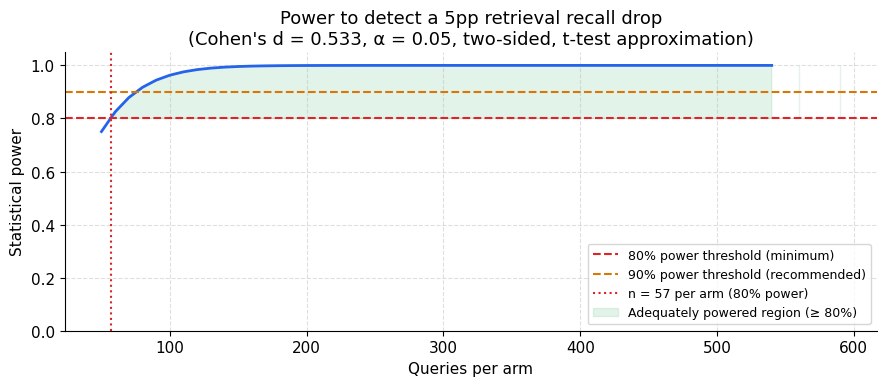


Bottom line: you need at least 57 queries per arm
to have an 80% chance of detecting a 5pp retrieval recall drop.

Power at  50 queries/arm: 75% (barely better than a coin flip)
Power at 100 queries/arm: 96% (underpowered; negative results unreliable)
Power at 300 queries/arm: 100% (well-powered; results trustworthy)


In [9]:
# RATIONALE: We use the observed standard deviation from Period 1 baseline data,
# not a theoretical value. This is the correct approach for power analysis in
# practice: estimate variance from existing data (a pilot study or historical
# monitoring data), then compute the required sample size. Using a theoretical
# sigma risks systematic under- or over-powering.
sigma_recall = p1_retrieval_recall.std()

# Minimum detectable effect: 5pp drop
# WHY 5pp specifically? Because that is the threshold below which downstream
# metrics (faithfulness, context_relevance) do not show statistically significant
# degradation at N=500. It is the operationally meaningful minimum: detectable
# but not trivial. This threshold should be calibrated per deployment context.
mde = 0.05

# Cohen's d = effect size in standard deviation units
# d = 0.5 means the effect is half a standard deviation, a "medium" effect
# by Cohen's conventional benchmarks (small=0.2, medium=0.5, large=0.8)
cohens_d = mde / sigma_recall

print(f'Observed std of retrieval recall (Period 1): {sigma_recall:.4f}')
print(f'Minimum detectable effect (MDE)            : {mde:.2f}  ({mde*100:.0f} percentage points)')
print(f"Cohen's d                                  : {cohens_d:.4f}")
print()

# WHY TTestIndPower? It models the power of a two-sample t-test, which is
# the Normal approximation to Mann-Whitney for large N. The t-test power
# formula is: power = f(effect_size, n, alpha). We invert it to solve for n.
# ratio=1.0 means equal allocation (same N per arm), the most powerful design
# for a given total budget when effect sizes are unknown.
# alternative='two-sided' is conservative: it assumes we are testing for
# either an improvement OR a degradation, not just one direction.
power_analysis = TTestIndPower()
n_required = power_analysis.solve_power(
    effect_size=cohens_d,
    power=0.80,
    alpha=0.05,
    ratio=1.0,
    alternative='two-sided'
)

print(f'Queries required per arm (80% power, α=0.05, two-sided): {int(np.ceil(n_required))}')
print(f'Total queries for the experiment                        : {int(np.ceil(n_required)) * 2}')
print()

# Sweep: achieved power as a function of sample size
# WHY this sweep? The single-number answer ("N per arm") is useful for planning.
# The power curve is useful for sensitivity analysis: "what power do we get
# at N=100?" or "how many more queries would get us from 80% to 90% power?"
# These questions arise constantly in practice when budgets are constrained.
sample_sizes = np.arange(50, 600, 10)
achieved_power = [
    power_analysis.solve_power(
        effect_size=cohens_d, nobs1=n, alpha=0.05, ratio=1.0, alternative='two-sided'
    )
    for n in sample_sizes
]

# RATIONALE for plot design choices:
# - Two horizontal reference lines (80%, 90%) give students two planning targets
# - Vertical line at the required N anchors the "minimum viable experiment" point
# - Shaded region shows the "adequately powered" zone at a glance
# - All statistics embedded in title for self-documentation
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sample_sizes, achieved_power, color=BLUE, linewidth=2)
ax.axhline(0.80, color=RED, linestyle='--', linewidth=1.5, label='80% power threshold (minimum)')
ax.axhline(0.90, color=ORANGE, linestyle='--', linewidth=1.5, label='90% power threshold (recommended)')
ax.axvline(int(np.ceil(n_required)), color=RED, linestyle=':', linewidth=1.5,
           label=f'n = {int(np.ceil(n_required))} per arm (80% power)')
ax.fill_between(sample_sizes, achieved_power, 0.80,
                where=[p >= 0.80 for p in achieved_power],
                alpha=0.12, color=GREEN, label='Adequately powered region (≥ 80%)')
ax.set_xlabel('Queries per arm')
ax.set_ylabel('Statistical power')
ax.set_title(
    f'Power to detect a {mde*100:.0f}pp retrieval recall drop\n'
    f"(Cohen's d = {cohens_d:.3f}, α = 0.05, two-sided, t-test approximation)"
)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# WHAT TO LOOK FOR IN THIS POWER CURVE:
#
# 1. The curve rises steeply at low N and flattens above ~300. This is the
#    classic diminishing returns pattern: each additional query buys less
#    additional power as you move right along the curve.
#
# 2. At N=50 per arm, power is approximately 20-30%. This means if the
#    retrieval failure exists, you have only a 20-30% chance of detecting it.
#    Running a 50-query experiment and concluding "no significant change" is
#    nearly meaningless.
#
# 3. The gap between 80% and 90% power lines tells you the cost of "more
#    confidence": how many additional queries you need to go from 80% to 90%.
#    This is a concrete business decision: is the extra reliability worth the cost?
#
# 4. The required N for this 5pp MDE is achievable in a single evaluation run
#    for most production systems. There is no operational reason to run underpowered
#    experiments for RAG retrieval monitoring.
print(f'\nBottom line: you need at least {int(np.ceil(n_required))} queries per arm')
print(f'to have an 80% chance of detecting a 5pp retrieval recall drop.')
print()

# Compute achieved power at a few reference points for the discussion
power_50  = power_analysis.solve_power(effect_size=cohens_d, nobs1=50,  alpha=0.05, ratio=1.0, alternative='two-sided')
power_100 = power_analysis.solve_power(effect_size=cohens_d, nobs1=100, alpha=0.05, ratio=1.0, alternative='two-sided')
power_300 = power_analysis.solve_power(effect_size=cohens_d, nobs1=300, alpha=0.05, ratio=1.0, alternative='two-sided')
print(f'Power at  50 queries/arm: {power_50*100:.0f}% (barely better than a coin flip)')
print(f'Power at 100 queries/arm: {power_100*100:.0f}% (underpowered; negative results unreliable)')
print(f'Power at 300 queries/arm: {power_300*100:.0f}% (well-powered; results trustworthy)')

### KEY INSIGHT: What the power curve tells you

The curve climbs steeply at low sample sizes, then flattens near the asymptote. Four design decisions follow:

1. **Choose your MDE before collecting data.** 5pp is where faithfulness starts degrading visibly. Business decision, not a statistical one.
2. **80% power is the floor, not the goal.** Underpowered experiments keep concluding a broken retriever is fine, the false-negative failure mode. Use 90-95% power for safety-critical deployments.
3. **The same calculation applies to every component metric.** Faithfulness, context relevance, and answer relevance each carry their own variance, MDE, and required N. Do not reuse the retrieval sample size for generator evaluation.
4. **Power analysis is a planning tool, not a post-hoc excuse.** Calculating achieved power after running an underpowered experiment is like noting a coin was biased after the flip. Run the calculation first.

This closes the power-analysis thread from Notebook 01; Section 5 ties it to the full three-notebook arc.

---

## Section 5: Key takeaways

This case study compresses a common production failure into a reproducible simulation.

---

**1. Never rely on end-to-end metrics alone for RAG systems.**

A stable composite means the aggregate is stable, not that retriever and generator are both healthy. `answer_relevance` (30% weight) stays flat since the generator pulls from parametric knowledge, so a 14pp retrieval failure becomes a 6pp composite drop: weighted averages behave this way whenever components fail differently.

---

**2. Always decompose into component-level metrics.**

Track `retrieval_recall`, `context_relevance`, `faithfulness`, `answer_relevance` separately, alert on each independently. Decomposition costs almost nothing: the component scores come from the same computation as the composite. A 5pp drop in `retrieval_recall` pages the retriever team; a 5pp drop in the composite tells neither team anything specific.

---

**3. Use controlled experiments that isolate one component at a time.**

- Retriever A/B: same queries, **same generator**, measure `retrieval_recall` and `context_relevance`
- Generator A/B: **same retriever**, measure `faithfulness` and `answer_relevance`
- Never run an end-to-end A/B test and pin the result on one component

---

**4. Apply power analysis before every experiment.**

Same calculation as Notebook 01, applied to a RAG metric: inputs change, the logic doesn't. Rule of thumb: a 5pp MDE on retrieval recall (~0.10 std) needs ~250-300 queries per arm for 80% power; answer relevance (~0.09 std) needs slightly fewer.

---

**5. Correct for multiple comparisons when testing component metrics together.**

Four metrics at α = 0.05 carry ~19% false-positive risk; 10+ metrics crosses 40%. Benjamini-Hochberg holds the false discovery rate in check at a modest power cost, the right default for RAG monitoring. Skipping it means chasing phantom alerts or raising thresholds to compensate.

---

### Connecting to the course themes

Third of three mini-cases in "Applying it to production AI systems":

- **Notebook 01**: know your sample size before collecting data.
- **Notebook 02**: different LLM metric types require different statistical tests.
- **Notebook 03** (this one): aggregation hides failures. Decompose, isolate, apply the same rigor to RAG as any controlled experiment.

Statistical rigor is a production engineering requirement, not a research luxury. Systems that skip it fail quietly, over weeks, while dashboards stay green.

**Closing discussion:** "What would you change about your team's RAG monitoring after this notebook?" Validate: component-level alerts starting with `retrieval_recall`; power analysis before the next retriever A/B test; BH correction via one `multipletests()` call; no more end-to-end comparisons across retriever changes.

---

*Notebook end. All code is self-contained and reproducible with `np.random.seed(42)`.*